In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

from outliers import calculate_iqr, find_outliers_via_forest, z_score
from features import extract_features, prepare_data, split_data
from evaluate import (
    evaluate_classification,
    plot_confusion_matrix,
    plot_correlation,
    save_evaluation_metrics,
    show_results,
)
from define_pipeline import create_pipeline, tuning


RANDOM_STATE = 777

In [2]:
df = pd.read_csv(filepath_or_buffer="Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [4]:
df["customer_id"].unique().shape

(10000,)

In [5]:
df = df.drop(columns="customer_id")

### **Detecting Outliers & Anomalies**

In [6]:
numerical_cols = (
    df
    .drop(columns="churn")
    .select_dtypes(include=[np.number])
    .columns
)

anomalies = find_outliers_via_forest(
    df=df, 
    numerical_cols=numerical_cols, 
    contamination=0.05,
    to_scale=False
)

df = pd.concat(objs=[df, anomalies], ignore_index=False, axis="columns")

In [7]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,anomaly,score
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.094068
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.070199
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,0.028907
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,0.056492
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,0.079036


In [8]:
df.shape

(10000, 13)

In [9]:
df_anomalies = df[df["anomaly"] == -1]
df = df[df["anomaly"] == 1]

In [10]:
df.shape

(9500, 13)

### **Label Encoding**

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      9500 non-null   int64  
 1   country           9500 non-null   str    
 2   gender            9500 non-null   str    
 3   age               9500 non-null   int64  
 4   tenure            9500 non-null   int64  
 5   balance           9500 non-null   float64
 6   products_number   9500 non-null   int64  
 7   credit_card       9500 non-null   int64  
 8   active_member     9500 non-null   int64  
 9   estimated_salary  9500 non-null   float64
 10  churn             9500 non-null   int64  
 11  anomaly           9500 non-null   int64  
 12  score             9500 non-null   float64
dtypes: float64(3), int64(8), str(2)
memory usage: 1.0 MB


In [12]:
df["country"].value_counts()

country
France     4756
Germany    2389
Spain      2355
Name: count, dtype: int64

In [13]:
df["gender"].value_counts()

gender
Male      5222
Female    4278
Name: count, dtype: int64

In [14]:
def onehot_encode(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    encoder = OneHotEncoder(sparse_output=False)
    encoded = encoder.fit_transform(df[[column_name]])

    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out([column_name]),
        index=df.index
    )

    new_df = pd.concat([df.drop(columns=[column_name]), encoded_df], axis=1)

    return new_df

In [15]:
df = onehot_encode(df=df, column_name="country")
df = onehot_encode(df=df, column_name="gender")

In [16]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,anomaly,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0.094068,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0.070199,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.028907,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0.056492,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0.079036,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0.113057,1.0,0.0,0.0,0.0,1.0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0.053949,1.0,0.0,0.0,0.0,1.0
9997,709,36,7,0.00,1,0,1,42085.58,1,1,0.045117,1.0,0.0,0.0,1.0,0.0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0.103756,0.0,1.0,0.0,0.0,1.0


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      9500 non-null   int64  
 1   age               9500 non-null   int64  
 2   tenure            9500 non-null   int64  
 3   balance           9500 non-null   float64
 4   products_number   9500 non-null   int64  
 5   credit_card       9500 non-null   int64  
 6   active_member     9500 non-null   int64  
 7   estimated_salary  9500 non-null   float64
 8   churn             9500 non-null   int64  
 9   anomaly           9500 non-null   int64  
 10  score             9500 non-null   float64
 11  country_France    9500 non-null   float64
 12  country_Germany   9500 non-null   float64
 13  country_Spain     9500 non-null   float64
 14  gender_Female     9500 non-null   float64
 15  gender_Male       9500 non-null   float64
dtypes: float64(8), int64(8)
memory usage: 1.2 MB


In [18]:
df = df.drop(columns="anomaly")

### **Finding Correlation**

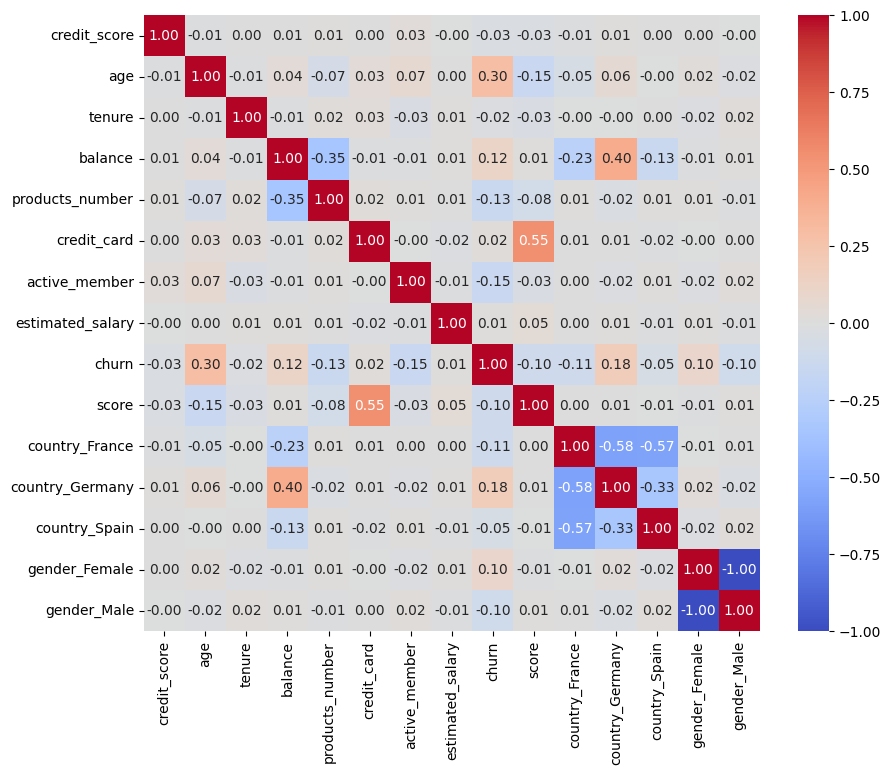

In [19]:
plot_correlation(df=df, method="pearson", cmap="coolwarm")

### **Saving Prepared Dataset**

In [21]:
df.to_csv(path_or_buf="bank_churn_prepared.csv", index=False)

### **Random Forest Classifier**

In [22]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y)

In [23]:
df_pipeline

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0.094068,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0.070199,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,0.028907,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0.056492,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0.079036,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,771,39,5,0.00,2,1,0,96270.64,0.113057,1.0,0.0,0.0,0.0,1.0
9496,516,35,10,57369.61,1,1,1,101699.77,0.053949,1.0,0.0,0.0,0.0,1.0
9497,709,36,7,0.00,1,0,1,42085.58,0.045117,1.0,0.0,0.0,1.0,0.0
9498,772,42,3,75075.31,2,1,0,92888.52,0.103756,0.0,1.0,0.0,0.0,1.0


In [24]:
X_train

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
2368,714,28,6,122724.37,1,1,1,67057.27,0.110588,1.0,0.0,0.0,0.0,1.0
8603,704,33,0,130499.09,2,1,1,74804.36,0.081192,1.0,0.0,0.0,1.0,0.0
8040,850,34,4,71379.53,2,1,1,154000.99,0.072496,1.0,0.0,0.0,1.0,0.0
3295,538,42,1,98548.62,2,0,1,94047.75,0.055787,0.0,1.0,0.0,1.0,0.0
6370,681,49,8,142946.18,1,0,0,187280.51,0.033774,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,631,34,4,124379.14,1,1,0,106892.91,0.144652,1.0,0.0,0.0,1.0,0.0
8781,546,25,3,132837.70,1,1,0,131647.31,0.091047,0.0,1.0,0.0,1.0,0.0
8926,766,52,7,92510.90,2,0,1,66193.61,0.028532,1.0,0.0,0.0,1.0,0.0
2195,781,32,6,147107.91,1,1,1,40066.95,0.087516,1.0,0.0,0.0,0.0,1.0


In [25]:
y_train

2368    0
8603    0
8040    0
3295    0
6370    1
       ..
1562    0
8781    0
8926    0
2195    0
1661    0
Name: churn, Length: 7600, dtype: int64

In [26]:
df_pipeline

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0.094068,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0.070199,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,0.028907,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0.056492,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0.079036,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,771,39,5,0.00,2,1,0,96270.64,0.113057,1.0,0.0,0.0,0.0,1.0
9496,516,35,10,57369.61,1,1,1,101699.77,0.053949,1.0,0.0,0.0,0.0,1.0
9497,709,36,7,0.00,1,0,1,42085.58,0.045117,1.0,0.0,0.0,1.0,0.0
9498,772,42,3,75075.31,2,1,0,92888.52,0.103756,0.0,1.0,0.0,0.0,1.0


In [27]:
model = RandomForestClassifier(
    n_estimators=500,        
    max_depth=20,            
    min_samples_split=5,     
    min_samples_leaf=2,      
    max_features="sqrt",     
    bootstrap=True,          
    n_jobs=-1,               
    random_state=RANDOM_STATE
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=None
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1537
           1       0.76      0.37      0.50       363

    accuracy                           0.86      1900
   macro avg       0.82      0.67      0.71      1900
weighted avg       0.85      0.86      0.84      1900

accuracy: 0.86
precision: 0.85
recall: 0.86
f1: 0.84


In [28]:
pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

param_dist = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

pipeline_tuned = tuning(
    param_dist=param_dist,
    pipeline=pipeline,
    scoring="f1_weighted",
    random_state=777
)
pipeline_tuned.fit(X_train, y_train)

pipeline_best_model = pipeline_tuned.best_estimator_

evaluation_metrics = evaluate_classification(
    model=pipeline_best_model,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1537
           1       0.76      0.37      0.50       363

    accuracy                           0.86      1900
   macro avg       0.82      0.67      0.71      1900
weighted avg       0.85      0.86      0.84      1900

accuracy: 0.86
precision: 0.85
recall: 0.86
f1: 0.84


### **Extreme Random Trees**

In [29]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y)

In [30]:
model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=False,
    criterion="gini",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1537
           1       0.69      0.35      0.46       363

    accuracy                           0.85      1900
   macro avg       0.78      0.66      0.69      1900
weighted avg       0.83      0.85      0.82      1900

accuracy: 0.85
precision: 0.83
recall: 0.85
f1: 0.82


In [31]:
param_dist = {
    "model__n_estimators": np.arange(200, 1200, 100),
    "model__max_depth": [None] + list(range(3, 30)),
    "model__min_samples_split": np.arange(2, 20),
    "model__min_samples_leaf": np.arange(1, 20),
    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"]
}

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features
)
pipeline_tuned = tuning(
    param_dist=param_dist,
    pipeline=pipeline,
    scoring="f1_weighted",
    random_state=RANDOM_STATE
)

pipeline_tuned.fit(X_train, y_train)

pipeline_best_model = pipeline_tuned.best_estimator_

evaluation_metrics = evaluate_classification(
    model=pipeline_best_model,
    X_test=X_test,
    y_test=y_test,
    include_cm=False,
    include_roc_auc=False,
    average="weighted",
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1537
           1       0.72      0.42      0.53       363

    accuracy                           0.86      1900
   macro avg       0.80      0.69      0.72      1900
weighted avg       0.84      0.86      0.84      1900

accuracy: 0.86
precision: 0.84
recall: 0.86
f1: 0.84


### **Gradient Boosting Classifier**

In [32]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y)

In [33]:
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=777
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1537
           1       0.72      0.40      0.51       363

    accuracy                           0.86      1900
   macro avg       0.80      0.68      0.71      1900
weighted avg       0.84      0.86      0.84      1900

accuracy: 0.86
precision: 0.84
recall: 0.86
f1: 0.84


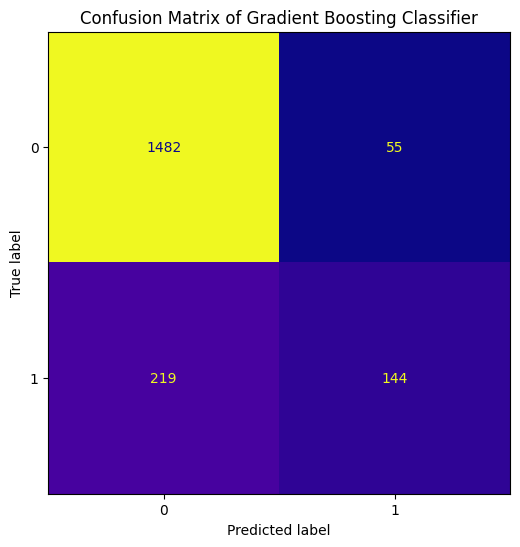

In [41]:
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_true=y_test, y_pred=y_pred, plot_title="Confusion Matrix of Gradient Boosting Classifier", cmap="plasma")

### **Extreme Gradient Boosting**

In [7]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y)

In [8]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss",
    objective="binary:logistic",
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1537
           1       0.72      0.40      0.52       363

    accuracy                           0.86      1900
   macro avg       0.80      0.68      0.72      1900
weighted avg       0.84      0.86      0.84      1900

accuracy: 0.86
precision: 0.84
recall: 0.86
f1: 0.84


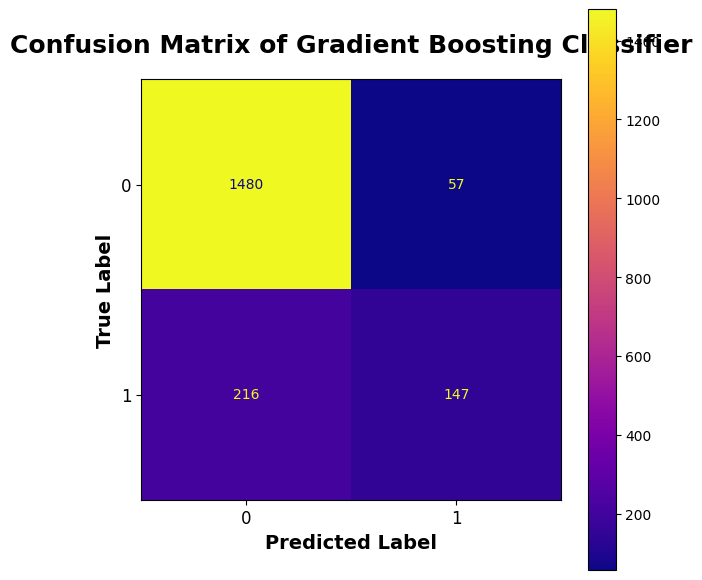

In [9]:
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_true=y_test, y_pred=y_pred, plot_title="Confusion Matrix of Gradient Boosting Classifier", cmap="plasma")

### **Ada Boosting Classifier**

In [6]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y, test_size=0.4)

In [7]:
model = AdaBoostClassifier(
    estimator=None,   # If None, then the base estimator is DecisionTreeClassifier 
                      # initialized with max_depth=1.
    n_estimators=50, 
    learning_rate=1.0, 
    random_state=None
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      3074
           1       0.68      0.41      0.51       726

    accuracy                           0.85      3800
   macro avg       0.78      0.68      0.71      3800
weighted avg       0.84      0.85      0.83      3800

accuracy: 0.85
precision: 0.84
recall: 0.85
f1: 0.83


In [8]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": np.logspace(-2, 0, 8),

    "model__estimator": [DecisionTreeClassifier()],
    "model__estimator__max_depth": [1, 2, 3],
    "model__estimator__min_samples_split": [2, 5, 10],
    "model__estimator__min_samples_leaf": [1, 2, 4]
}

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)
pipeline_tuned = tuning(
    param_dist=param_dist,
    pipeline=pipeline,
    scoring="f1_weighted",
)

pipeline_tuned.fit(X_train, y_train)

pipeline_best_model = pipeline_tuned.best_estimator_

evaluation_metrics = evaluate_classification(
    model=pipeline_best_model,
    X_test=X_test,
    y_test=y_test,
    include_cm=False,
    include_roc_auc=False,
    average="weighted",
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      3074
           1       0.72      0.42      0.53       726

    accuracy                           0.86      3800
   macro avg       0.80      0.69      0.73      3800
weighted avg       0.85      0.86      0.84      3800

accuracy: 0.86
precision: 0.85
recall: 0.86
f1: 0.84


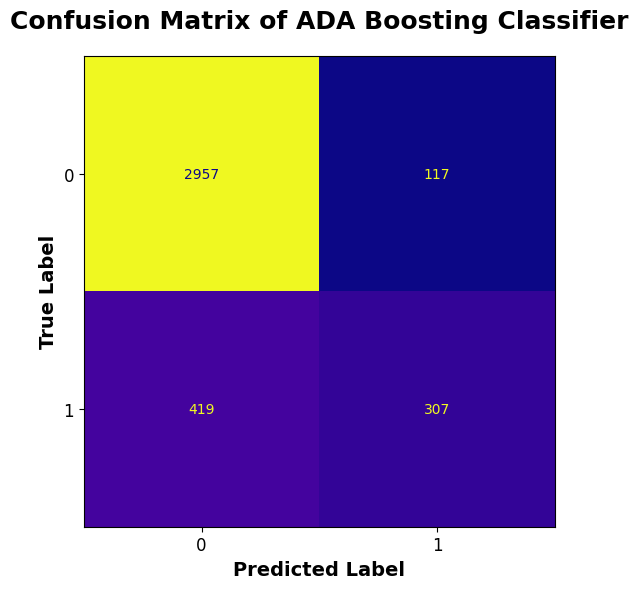

In [10]:
y_pred = pipeline_best_model.predict(X_test)

plot_confusion_matrix(y_true=y_test, y_pred=y_pred, plot_title="Confusion Matrix of ADA Boosting Classifier", cmap="plasma")

### **MLP Classifier**

In [12]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y, test_size=0.4)

In [18]:
model = MLPClassifier(
    hidden_layer_sizes=(100,), 
    activation='relu',
    solver='adam', 
    alpha=0.0001, 
    batch_size='auto', 
    learning_rate='constant', 
    learning_rate_init=0.001,
    max_iter=600
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3074
           1       0.61      0.40      0.48       726

    accuracy                           0.84      3800
   macro avg       0.74      0.67      0.69      3800
weighted avg       0.82      0.84      0.82      3800

accuracy: 0.84
precision: 0.82
recall: 0.84
f1: 0.82


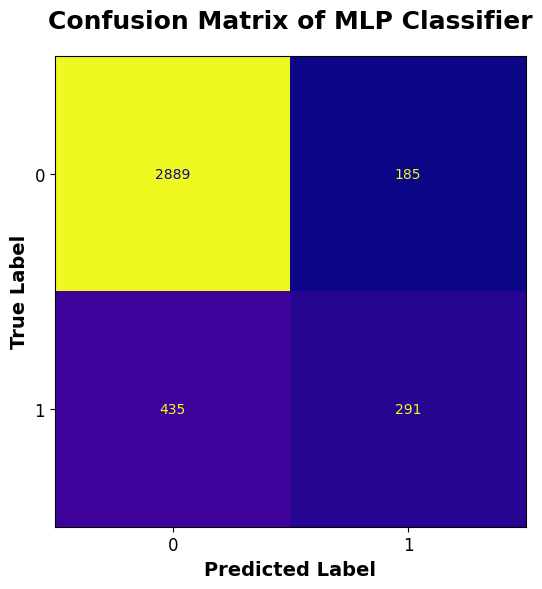

In [19]:
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_true=y_test, y_pred=y_pred, plot_title="Confusion Matrix of MLP Classifier", cmap="plasma")

### **SGD Classifier**

In [22]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    target_column="churn",
    columns_to_drop="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y, test_size=0.2)

In [23]:
model = SGDClassifier(
    loss='hinge', 
    penalty='l2', 
    alpha=0.0001, 
    l1_ratio=0.15, 
    fit_intercept=True, 
    max_iter=1000, 
    tol=0.001, 
    shuffle=True, 
    verbose=0, 
    epsilon=0.1, 
    n_jobs=-1, 
    random_state=RANDOM_STATE, 
    learning_rate='optimal', 
    eta0=0.01, 
    power_t=0.5, 
    early_stopping=False, 
    validation_fraction=0.1, 
    n_iter_no_change=5, 
    class_weight=None, 
    warm_start=False, 
    average=False
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=OneHotEncoder()
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    include_cm=False,
    include_roc_auc=False,
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics, to_round=True, decimals=2)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      1537
           1       0.67      0.10      0.18       363

    accuracy                           0.82      1900
   macro avg       0.75      0.55      0.54      1900
weighted avg       0.79      0.82      0.76      1900

accuracy: 0.82
precision: 0.79
recall: 0.82
f1: 0.76


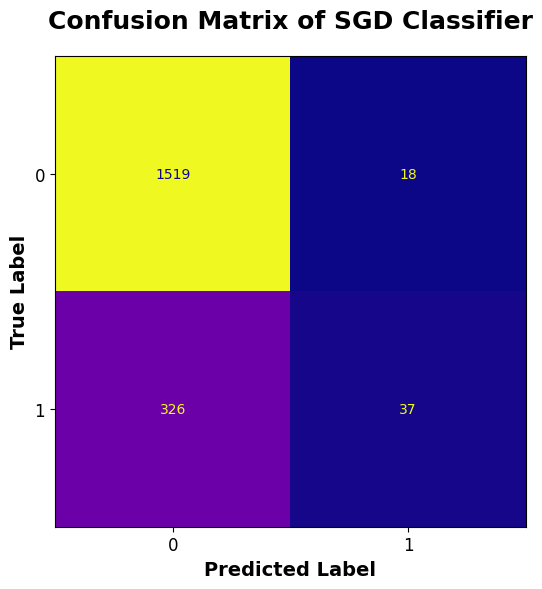

In [25]:
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_true=y_test, y_pred=y_pred, plot_title="Confusion Matrix of SGD Classifier", cmap="plasma")